# 03 LightGBM Training

Train and evaluate LightGBM with 5-fold CV. Then train the final serving model on all available training rows.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from amex_default.config import PLOTS_DIR, REPORTS_DIR
from amex_default.data import get_feature_columns, load_train_features, split_features_target
from amex_default.train_lightgbm import save_cv_artifacts, save_final_model, train_cv, train_final_model

/Users/komalpreet/miniconda3/envs/inflection/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = load_train_features()
X, y = split_features_target(df)
feature_cols = get_feature_columns(df)

print(f"Rows: {len(df):,}")
print(f"Features: {len(feature_cols):,}")
print(y.value_counts(normalize=True))


Rows: 229,456
Features: 3,418
target
0    0.741066
1    0.258934
Name: proportion, dtype: float64



LightGBM fold 1
Training until validation scores don't improve for 50 rounds
[100]	valid's auc: 0.95609
[200]	valid's auc: 0.957677
[300]	valid's auc: 0.957889
Early stopping, best iteration is:
[341]	valid's auc: 0.958
Fold 1 ROC-AUC: 0.9580

LightGBM fold 2
Training until validation scores don't improve for 50 rounds
[100]	valid's auc: 0.957762
[200]	valid's auc: 0.959252
[300]	valid's auc: 0.959513
Early stopping, best iteration is:
[309]	valid's auc: 0.959528
Fold 2 ROC-AUC: 0.9595

LightGBM fold 3
Training until validation scores don't improve for 50 rounds
[100]	valid's auc: 0.95823
[200]	valid's auc: 0.959822
[300]	valid's auc: 0.959984
Early stopping, best iteration is:
[292]	valid's auc: 0.960012
Fold 3 ROC-AUC: 0.9600

LightGBM fold 4
Training until validation scores don't improve for 50 rounds
[100]	valid's auc: 0.957814
[200]	valid's auc: 0.959238
[300]	valid's auc: 0.959436
Early stopping, best iteration is:
[296]	valid's auc: 0.95946
Fold 4 ROC-AUC: 0.9595

LightGBM fold

,model,n_rows,n_features,roc_auc,pr_auc,precision,recall,f1,threshold,training_time_seconds,inference_time_seconds,total_time_seconds
0,lightgbm,229456,3418,0.959328,0.89382,0.810382,0.805854,0.808112,0.5,901.473069,1.775503,903.248572


,feature,fold_1,fold_2,fold_3,fold_4,fold_5,importance_mean,importance_std
2322,P_2_last_6m,327829.616064,360111.239768,241959.051361,343518.623938,368831.984207,328450.103068,50846.020621
2321,P_2_last_3m,165602.271330,201493.362358,287709.327627,218662.990261,197214.109666,214136.412248,45374.105103
2320,P_2_last,179723.079668,121101.411707,128067.583886,117018.154272,121770.557360,133536.157379,26120.077321
222,B_1_last,54622.001649,34012.612345,48208.905131,48613.104813,50350.655663,47161.455920,7777.005518
442,B_2_last,17834.423887,16398.743914,15236.524510,19272.090413,18451.784569,17438.713459,1618.281781
734,B_9_last,11832.979106,10957.611630,10432.384871,16458.670563,14995.101973,12935.349628,2648.012040
223,B_1_last_3m,10201.395395,13595.044189,9136.152233,13386.514299,15960.819794,12455.985182,2763.678320
2614,R_1_mean_3m,15062.876538,8801.847395,11736.059808,6611.081606,13065.067298,11055.386529,3368.693885
2328,P_2_mean_3m,6426.103175,7409.499831,23123.262619,8329.628970,6699.277647,10397.554449,7151.889805
2606,R_1_last,9004.391912,9689.522735,8140.238251,9580.854065,8665.795511,9016.160495,644.676165


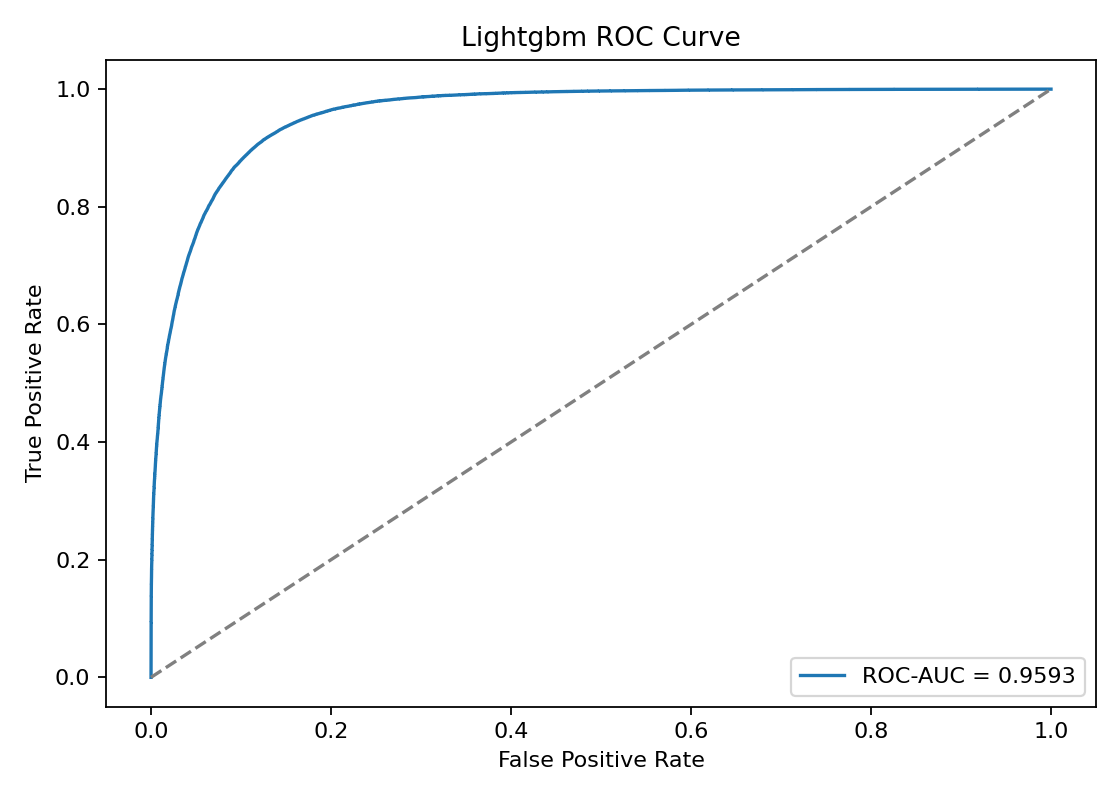

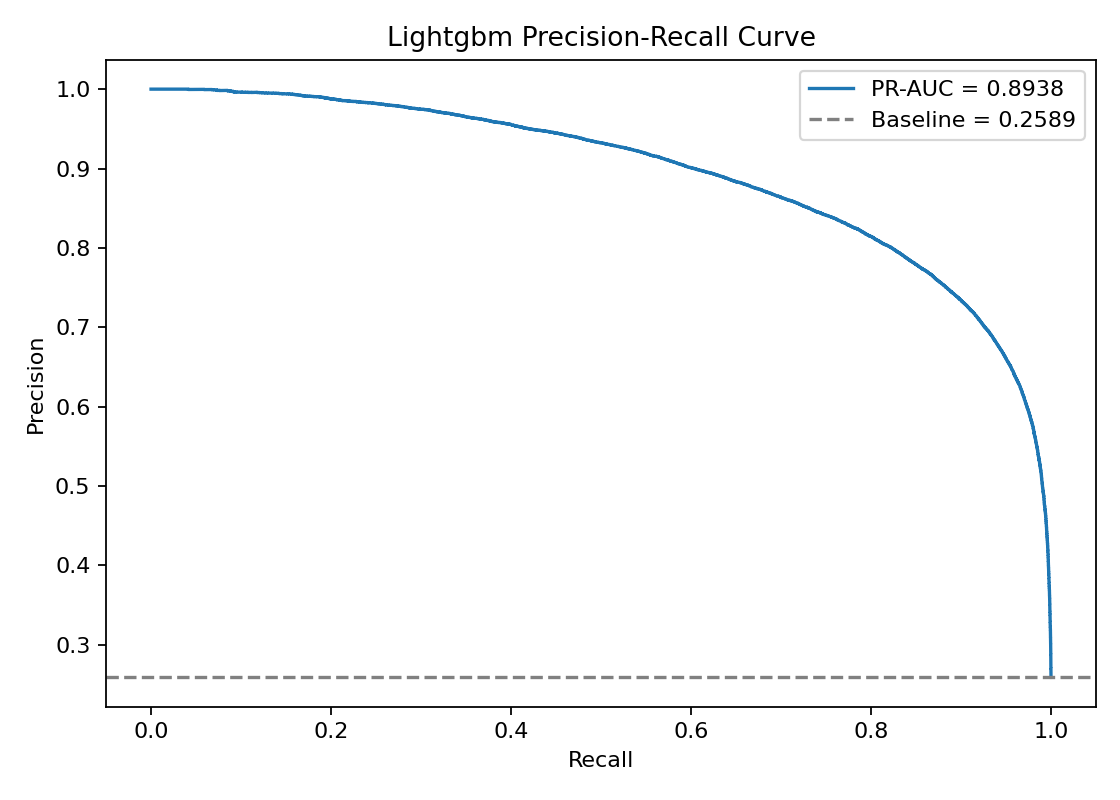

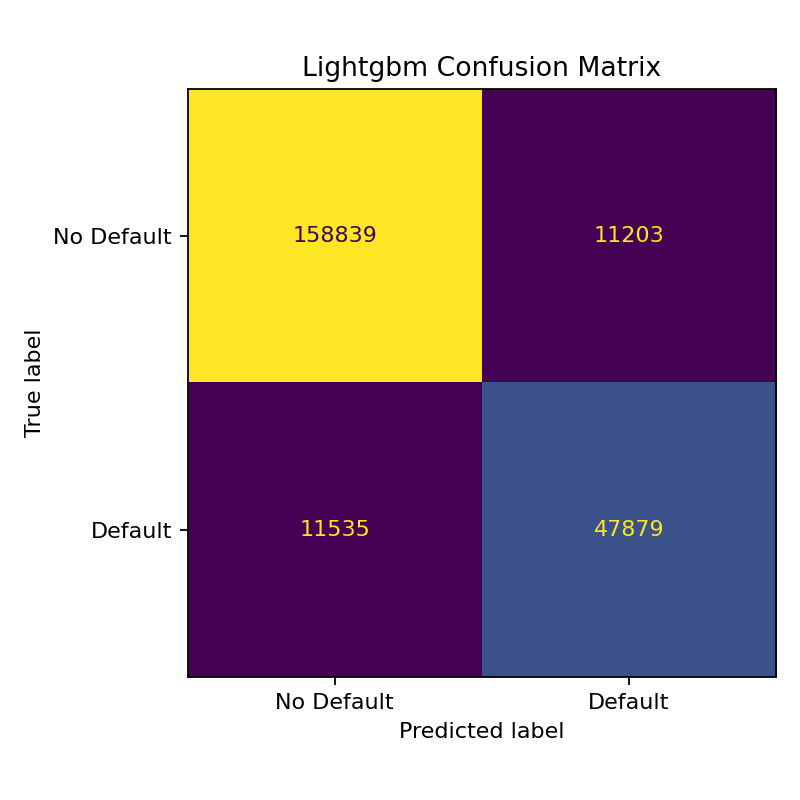

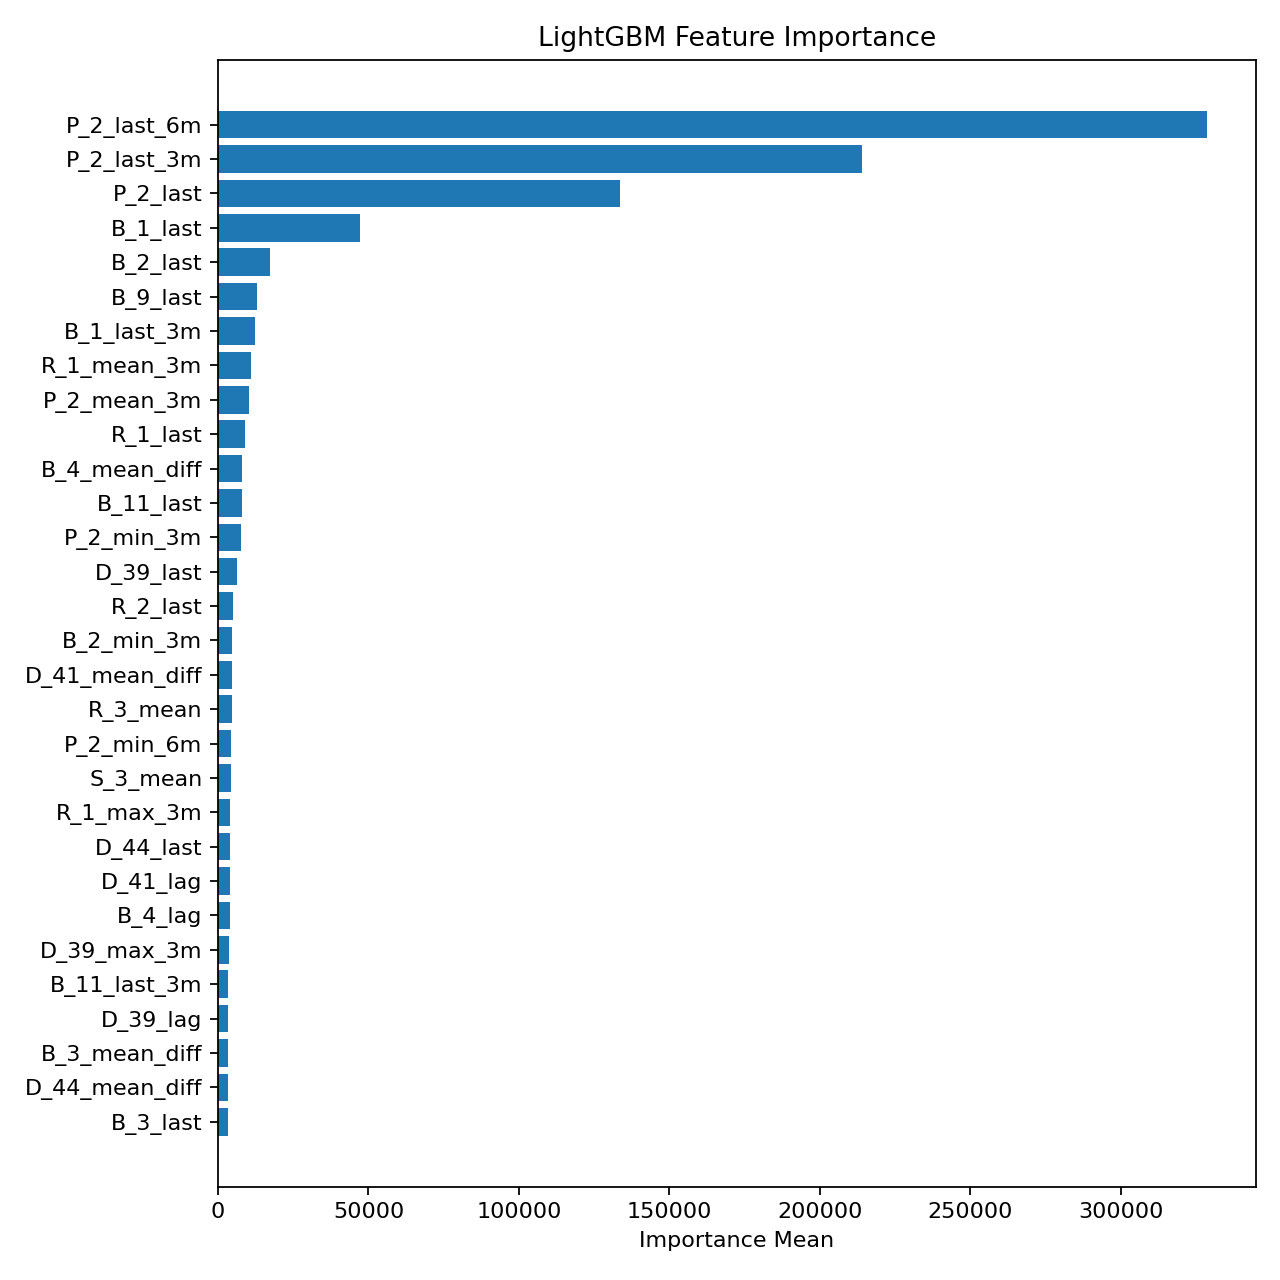

In [3]:
result = train_cv(X, y, customer_ids=df["customer_ID"])
save_cv_artifacts(result)

metrics = result["metrics"]
metric_cols = [
    "model", "n_rows", "n_features", "roc_auc", "pr_auc",
    "precision", "recall", "f1", "threshold",
    "training_time_seconds", "inference_time_seconds", "total_time_seconds",
]
display(pd.DataFrame([metrics]).reindex(columns=metric_cols))

display(result["feature_importance"].head(20))

for filename in [
    "lightgbm_roc_curve.png",
    "lightgbm_pr_curve.png",
    "lightgbm_confusion_matrix.png",
    "lightgbm_feature_importance.png",
]:
    display(Image(filename=str(PLOTS_DIR / filename)))

In [4]:
final_model = train_final_model(X, y)
save_final_model(final_model, feature_cols, metrics=result["metrics"])
print("Saved final LightGBM serving model.")

Saved final LightGBM serving model.
